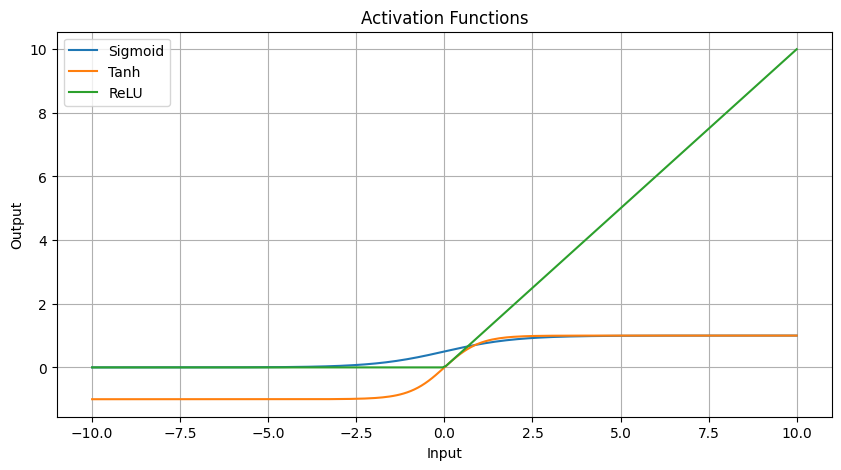

In [2]:
# Student Name : Mohamed Aslam A
# Roll No : 24BAD073

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 200)

sigmoid = 1/(1+np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)

plt.figure(figsize=(10,5))

plt.plot(x, sigmoid, label="Sigmoid")
plt.plot(x, tanh, label="Tanh")
plt.plot(x, relu, label="ReLU")

plt.title("Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)
plt.legend()
plt.show()

In [3]:
# Student Name : Mohamed Aslam A
# Roll No : 24BAD073

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

columns = [
'SampleCodeNumber','ClumpThickness','UniformityCellSize',
'UniformityCellShape','MarginalAdhesion',
'SingleEpithelialCellSize','BareNuclei',
'BlandChromatin','NormalNucleoli','Mitoses','Class'
]

df = pd.read_csv("breast-cancer-wisconsin.data", names=columns)

df.replace("?", np.nan, inplace=True)
df.dropna(inplace=True)
df["BareNuclei"] = df["BareNuclei"].astype(float)
df["Class"] = df["Class"].replace({2:0,4:1})

X = df.drop(["SampleCodeNumber","Class"], axis=1)
y = df["Class"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

activations = ["sigmoid","tanh","relu"]

for act in activations:

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation=act, input_shape=(9,)),
        tf.keras.layers.Dense(8, activation=act),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    print("\nActivation Function :", act)

    history = model.fit(
        X_train,
        y_train,
        epochs=20,
        validation_split=0.2,
        verbose=0
    )

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    print("Training Accuracy :", history.history["accuracy"][-1])
    print("Validation Accuracy :", history.history["val_accuracy"][-1])
    print("Training Loss :", history.history["loss"][-1])
    print("Validation Loss :", history.history["val_loss"][-1])
    print("Test Accuracy :", accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Activation Function : sigmoid
Training Accuracy : 0.9587156176567078
Validation Accuracy : 0.9363636374473572
Training Loss : 0.3943674564361572
Validation Loss : 0.4020310342311859
Test Accuracy : 0.9197080135345459

Activation Function : tanh
Training Accuracy : 0.9724770784378052
Validation Accuracy : 0.9545454382896423
Training Loss : 0.10135297477245331
Validation Loss : 0.14862903952598572
Test Accuracy : 0.956204354763031

Activation Function : relu
Training Accuracy : 0.9747706651687622
Validation Accuracy : 0.9545454382896423
Training Loss : 0.06947148591279984
Validation Loss : 0.12168042361736298
Test Accuracy : 0.9635036587715149



Optimizer : SGD
Training Accuracy : 0.9678899049758911
Validation Accuracy : 0.9545454382896423
Training Loss : 0.1453346610069275
Validation Loss : 0.17496967315673828
Test Accuracy : 0.9489051103591919

Optimizer : Momentum
Training Accuracy : 0.9724770784378052
Validation Accuracy : 0.9545454382896423
Training Loss : 0.06104019284248352
Validation Loss : 0.11601388454437256
Test Accuracy : 0.956204354763031

Optimizer : RMSProp
Training Accuracy : 0.9770641922950745
Validation Accuracy : 0.9545454382896423
Training Loss : 0.07267337292432785
Validation Loss : 0.1300220936536789
Test Accuracy : 0.970802903175354

Optimizer : Adam
Training Accuracy : 0.9724770784378052
Validation Accuracy : 0.9545454382896423
Training Loss : 0.08084163069725037
Validation Loss : 0.12373480200767517
Test Accuracy : 0.970802903175354


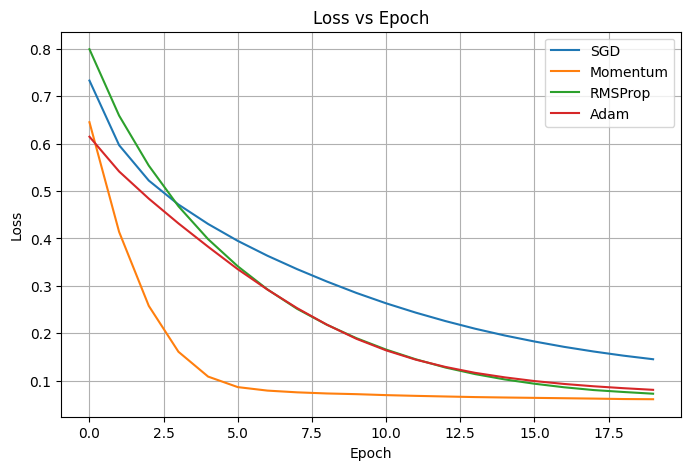

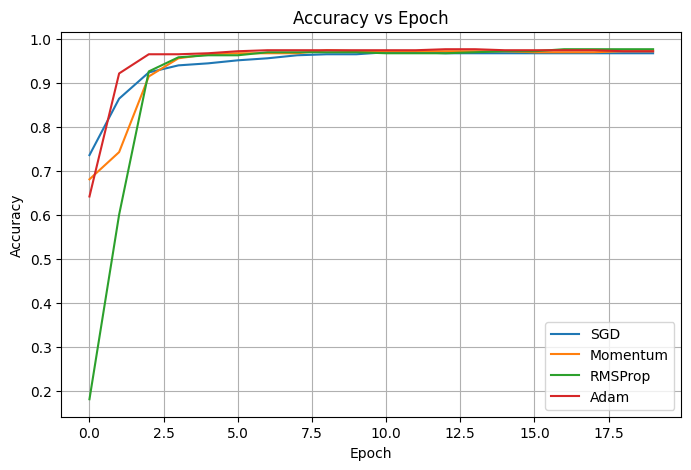

In [4]:
# Student Name : Mohamed Aslam A
# Roll No : 24BAD073

import matplotlib.pyplot as plt

optimizers = {
    "SGD": tf.keras.optimizers.SGD(),
    "Momentum": tf.keras.optimizers.SGD(momentum=0.9),
    "RMSProp": tf.keras.optimizers.RMSprop(),
    "Adam": tf.keras.optimizers.Adam()
}

histories = {}

for name, optimizer in optimizers.items():

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(16, activation="relu", input_shape=(9,)),
        tf.keras.layers.Dense(8, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    print("\nOptimizer :", name)

    history = model.fit(
        X_train,
        y_train,
        epochs=20,
        validation_split=0.2,
        verbose=0
    )

    histories[name] = history

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    print("Training Accuracy :", history.history["accuracy"][-1])
    print("Validation Accuracy :", history.history["val_accuracy"][-1])
    print("Training Loss :", history.history["loss"][-1])
    print("Validation Loss :", history.history["val_loss"][-1])
    print("Test Accuracy :", accuracy)

plt.figure(figsize=(8,5))

for name, history in histories.items():
    plt.plot(history.history["loss"], label=name)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))

for name, history in histories.items():
    plt.plot(history.history["accuracy"], label=name)

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()